# Customer response prediction

## Data Description:

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers

X1 = my order was delivered on time

X2 = contents of my order was as I expected

X3 = I ordered everything I wanted to order

X4 = I paid a good price for my order

X5 = I am satisfied with my courier

X6 = the app makes ordering easy for me

Attributes X1 to X6 indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.

## Goal(s):

Predict if a customer is happy or not based on the answers they give to questions asked.

## Success Metrics:

Reach 73% accuracy score or above.

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

## Exploratory data analysis

In [5]:
# Import data as a pandas dataframe
df = pd.read_csv("ACME-HappinessSurvey2020.csv")

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


1. Dataset does not have any missing values
2. All data points are integer type

In [8]:
df.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


1. "Y" column is a balanced dataset. Neither category in excess.
2. All "X" column values are between 1 and 5

In [10]:
# View a small sample of the dataset
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [11]:
df["Y"].unique()

array([0, 1])

Target variable "Y" is binary.

<Axes: >

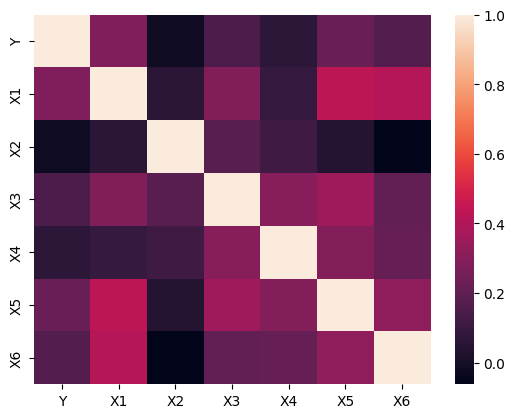

In [13]:
sns.heatmap(df.corr())

Default correlation method in pandas is Pearson, which assumes a linear relationship among variables. We also need to test non-linear relationships using Spearman correlation.

In [15]:
df.corr(method="spearman")

,Y,X1,X2,X3,X4,X5,X6
Y,1.000000,0.291458,-0.034304,0.162199,0.081398,0.227306,0.174114
X1,0.291458,1.000000,0.015683,0.228081,0.065851,0.422786,0.512855
X2,-0.034304,0.015683,1.000000,0.156817,0.136659,0.030070,-0.037147
X3,0.162199,0.228081,0.156817,1.000000,0.275266,0.406356,0.179754
X4,0.081398,0.065851,0.136659,0.275266,1.000000,0.305012,0.141381
X5,0.227306,0.422786,0.030070,0.406356,0.305012,1.000000,0.330066
X6,0.174114,0.512855,-0.037147,0.179754,0.141381,0.330066,1.000000


1. No strong correlations among features and target
2. X2 and X4 show the weakest correlation with Y

In [17]:
features = ["X1", "X2", "X3", "X4", "X5", "X6"]
target = "Y"

In [18]:
X = df[features].copy()
y = df[target].copy()

In [19]:
p_values = []
rho_values = []
for col in features:
    rho, p = stats.spearmanr(df[col], df["Y"])
    p_values.append(p)
    rho_values.append(rho)

In [20]:
results = pd.DataFrame({"rho_values":rho_values, "p_values": p_values}, index=features).sort_values("p_values")
results

,rho_values,p_values
X1,0.291458,0.000929
X5,0.227306,0.010477
X6,0.174114,0.051191
X3,0.162199,0.069590
X4,0.081398,0.364889
X2,-0.034304,0.702950


Features X1 and X5 have the highest impact on Y, whereas X2 and X4 have the least (statistically significant) impact on Y.

## Data preprocessing

In [23]:
# Select statistically significant variable from features
new_features = ["X1", "X3", "X5", "X6"]
X_new= X[new_features].copy()

In [24]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, stratify=y, random_state=123)

In [25]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
cv = StratifiedKFold(n_splits=5, random_state=123, shuffle=True)

## Machine learning

In [28]:
#Logistic regression
log_reg = LogisticRegression(random_state=123)
log_reg_cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv,scoring="accuracy")
log_reg_cv_scores

array([0.65, 0.6 , 0.6 , 0.65, 0.5 ])

In [29]:
log_reg.fit(X_train_scaled, y_train)
log_reg.score(X_test_scaled, y_test)

0.6153846153846154

In [30]:
# KNN classifier
knn = KNeighborsClassifier(n_neighbors = 5)
knn_cv_scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv,scoring="accuracy")
knn_cv_scores

array([0.4 , 0.55, 0.75, 0.55, 0.65])

In [31]:
knn.fit(X_train_scaled, y_train)
knn.score(X_test_scaled, y_test)

0.7307692307692307

In [32]:
knn.score(X_train_scaled, y_train)

0.75

In [33]:
#Gradient boosting
gb = GradientBoostingClassifier(random_state=123)
gb_cv_scores = cross_val_score(gb, X_train_scaled, y_train, cv=cv,scoring="accuracy")
gb_cv_scores

array([0.55, 0.7 , 0.85, 0.6 , 0.5 ])

In [34]:
gb.fit(X_train_scaled, y_train)
gb.score(X_test_scaled, y_test)

0.6538461538461539

In [35]:
# XGBoost
xgbc = xgb.XGBClassifier()
xgbc_cv_scores = cross_val_score(xgbc, X_train_scaled, y_train, cv=cv,scoring="accuracy")
xgbc_cv_scores

array([0.6 , 0.65, 0.75, 0.6 , 0.6 ])

In [36]:
xgbc.fit(X_train_scaled, y_train)
xgbc.score(X_test_scaled, y_test)

0.6538461538461539

In [37]:
# Random forest
rf = RandomForestClassifier(random_state=123)
rf_cv_scores = cross_val_score(rf, X_train_scaled, y_train, cv=cv,scoring="accuracy")
rf_cv_scores

array([0.65, 0.7 , 0.8 , 0.6 , 0.55])

In [38]:
rf.fit(X_train_scaled, y_train)
rf.score(X_test_scaled, y_test)

0.6538461538461539

## Summary

KNN classifier is the only method that meets the goal. Accuracy scores for training and test data are 75% and 73.078% respectively. This suggests that the features and target have non-linear relationships.

Logistic regression did not work because the method assumes linear relationships among variables. On the other hand, features and target seem to have non-linear relationships.

Bagging and boosting methods did not work likely because the dataset is too small in size. Therefore the sample size was not large enough to catch trends in the data. These methods typically work well with larger datasets.